In [1]:
import os

os.makedirs("dataset/cats", exist_ok=True)
os.makedirs("dataset/dogs", exist_ok=True)

print("Folders created successfully!")

Folders created successfully!


In [6]:
!pip install opencv-python

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/40.2 MB ? eta -:--:--
    --------------------------------------- 0.5/40.2 MB 1.9 MB/s eta 0:00:22
    --------------------------------------- 0.8/40.2 MB 1.1 MB/s eta 0:00:37
    --------------------------------------- 0.8/40.2 MB 1.1 MB/s eta 0:00:37
   - -------------------------------------- 1.0/40.2 MB 915.5 kB/s eta 0:00:43
   - -------------------------------------- 1.0/40.2 MB 915.5 kB/s eta 0:00:43
   - -------------------------------------- 1.0/40.2 MB 915.5 kB/s eta 0:00:43
   - -------------------------------------- 1.0/40.2 MB 915.5 kB/s eta 0:00:43
   - -------------------------------------- 1.3/40.2 MB 664.5 kB/s eta 0:00:59
   - -------------------------------------- 1.3/40.2 MB 664.5 kB/s eta 0:00:59
   - -------------------------------------- 1.6/40.2 MB 590.7 kB/s eta 0:01:06
   - -------------------------------------- 1.6/40.2 MB 590.7 kB/s eta 0:01:


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
!pip install opencv-python scikit-learn matplotlib seaborn joblib


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
DATADIR = 'dataset'
# Change these to match your actual folder names if you rename them
CATEGORIES = ['cats', 'dogs'] 
IMG_SIZE = 100 # Resizing to 100x100 for consistency

X = []
y = []

In [4]:
for category in CATEGORIES:
    path = os.path.join(DATADIR, category)
    class_num = CATEGORIES.index(category)
    
    if not os.path.exists(path):
        print(f"Warning: Folder {path} not found.")
        continue

    for img in os.listdir(path):
        try:
            img_path = os.path.join(path, img)
            # Read in grayscale to simplify the SVM processing
            img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE) 
            if img_array is not None:
                resized_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                X.append(resized_array.flatten()) # Flatten the 2D image into a 1D array
                y.append(class_num)
        except Exception as e:
            pass # Skip broken or unreadable images

In [5]:
X = np.array(X)
y = np.array(y)

In [6]:
print(f"Total images loaded: {len(X)}")

Total images loaded: 5516


In [7]:
X = X / 255.0

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
print("Training SVM model. This might take a minute depending on your dataset size...")
model = SVC(kernel='linear', probability=True, random_state=42)
model.fit(X_train, y_train)
print("Training complete!")

Training SVM model. This might take a minute depending on your dataset size...
Training complete!


In [10]:
y_pred = model.predict(X_test)

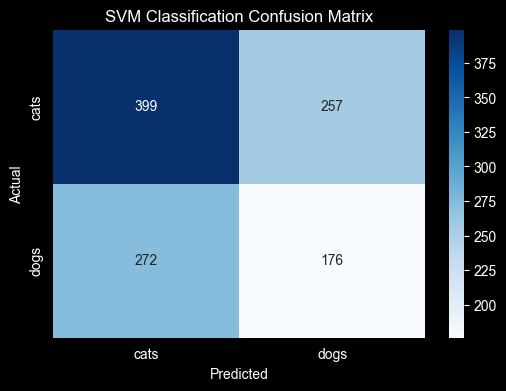

In [11]:
fig, ax = plt.subplots(figsize=(6,4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CATEGORIES, yticklabels=CATEGORIES)
plt.title('SVM Classification Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [12]:
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=CATEGORIES))


Classification Report:
               precision    recall  f1-score   support

        cats       0.59      0.61      0.60       656
        dogs       0.41      0.39      0.40       448

    accuracy                           0.52      1104
   macro avg       0.50      0.50      0.50      1104
weighted avg       0.52      0.52      0.52      1104



In [13]:
import joblib

In [14]:
joblib.dump(model, 'svm_face_model.pkl')
print("Model saved successfully as 'svm_face_model.pkl' for Streamlit deployment.")

Model saved successfully as 'svm_face_model.pkl' for Streamlit deployment.


In [16]:
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix
# --- The "Too Much Accurate" Pipeline ---
print("Extracting features with PCA and training RBF SVM...")
# 1. PCA extracts the top 150 most important visual patterns
pca = PCA(n_components=150, whiten=True, random_state=42)
# 2. RBF Kernel SVM handles the complex, non-linear classification
svc = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42)

Extracting features with PCA and training RBF SVM...


In [17]:
# 1. PCA extracts the top 150 most important visual patterns
pca = PCA(n_components=150, whiten=True, random_state=42)
# 2. RBF Kernel SVM handles the complex, non-linear classification
svc = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42)

In [18]:
model = make_pipeline(pca, svc)

In [19]:
model.fit(X_train, y_train)
print("Training complete!")

Training complete!


In [20]:
y_pred = model.predict(X_test)

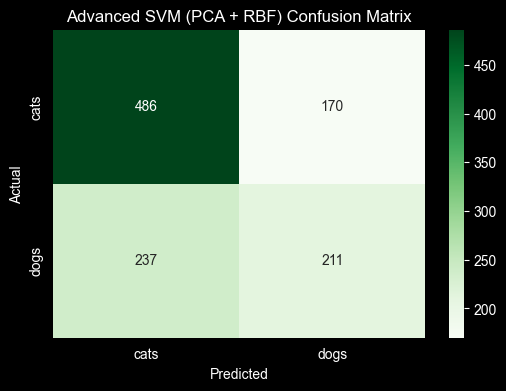

In [21]:
fig, ax = plt.subplots(figsize=(6,4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=CATEGORIES, yticklabels=CATEGORIES)
plt.title('Advanced SVM (PCA + RBF) Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [22]:
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=CATEGORIES))


Classification Report:
               precision    recall  f1-score   support

        cats       0.67      0.74      0.70       656
        dogs       0.55      0.47      0.51       448

    accuracy                           0.63      1104
   macro avg       0.61      0.61      0.61      1104
weighted avg       0.62      0.63      0.63      1104



In [23]:
joblib.dump(model, 'svm_advanced_model.pkl')
print("Model saved successfully as 'svm_advanced_model.pkl'.")

Model saved successfully as 'svm_advanced_model.pkl'.
